In [2]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

from src.config import FIG_DIR
from src.features import TARGET
from src.models import build_gbm, train_all

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

out = train_all()
gbm, ridge = out["gbm"], out["ridge"]
train, val, test = out["train"], out["val"], out["test"]
feats = out["feats"]

 train:  48,599 rows   2019-01-15 -> 2024-07-31
   val:   8,760 rows   2024-07-31 -> 2025-07-31
  test:   8,733 rows   2025-07-31 -> 2026-07-31

Validation results (baseline: Naive-24):

           model   MAE_MW  RMSE_MW  MAPE_pct  vs_baseline_pct
GradientBoosting  405.757  554.968     2.322           58.396
           Ridge  630.834  839.950     3.640           35.318
        Naive-24  975.286 1399.683     5.540            0.000
       Naive-168 1500.454 2202.822     8.306          -53.848


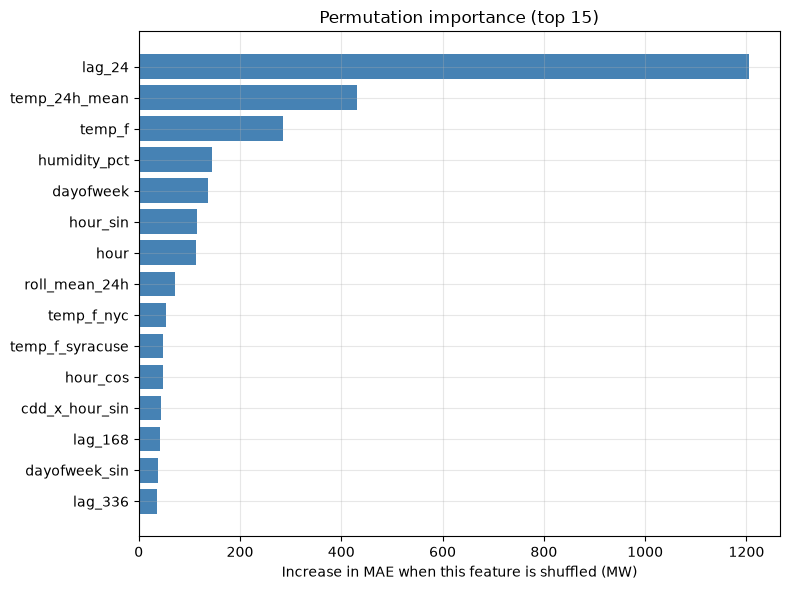

In [3]:
from sklearn.inspection import permutation_importance

sub = val.sample(5000, random_state=0)
imp = permutation_importance(gbm, sub[feats], sub[TARGET],
                             n_repeats=5, random_state=0, scoring="neg_mean_absolute_error")

order = imp.importances_mean.argsort()[-15:]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([feats[i] for i in order], imp.importances_mean[order], color="steelblue")
ax.set_title("Permutation importance (top 15)")
ax.set_xlabel("Increase in MAE when this feature is shuffled (MW)")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_feature_importance.png", dpi=130)
plt.show()

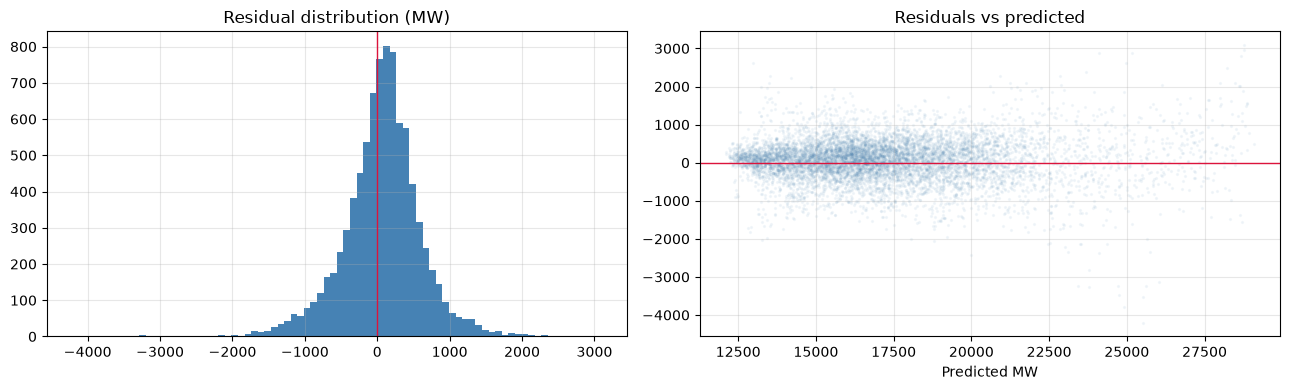

In [4]:
pred = gbm.predict(val[feats])
resid = val[TARGET].values - pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(resid, bins=80, color="steelblue")
axes[0].axvline(0, color="crimson", linewidth=1)
axes[0].set_title("Residual distribution (MW)")

axes[1].scatter(pred, resid, s=2, alpha=0.05, color="steelblue")
axes[1].axhline(0, color="crimson", linewidth=1)
axes[1].set_title("Residuals vs predicted")
axes[1].set_xlabel("Predicted MW")

fig.tight_layout()
fig.savefig(FIG_DIR / "08_residuals.png", dpi=130)
plt.show()

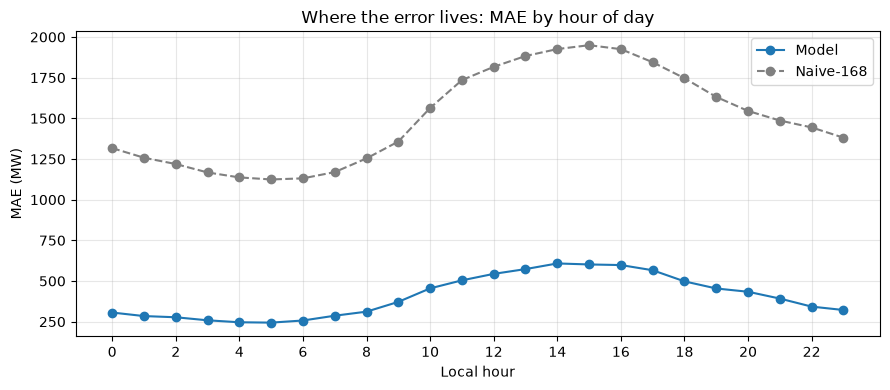

In [5]:
pred = gbm.predict(val[feats])
err = np.abs(val[TARGET].values - pred)
base_err = np.abs(val[TARGET].values - val["lag_168"].values)

hours = val["timestamp_local"].dt.hour
by_hour = val.assign(err=err).groupby(hours)["err"].mean()
base_by_hour = val.assign(err=base_err).groupby(hours)["err"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_hour.index, by_hour.values, marker="o", label="Model")
ax.plot(base_by_hour.index, base_by_hour.values, marker="o",
        linestyle="--", color="grey", label="Naive-168")
ax.set_title("Where the error lives: MAE by hour of day")
ax.set_xlabel("Local hour"); ax.set_ylabel("MAE (MW)")
ax.set_xticks(range(0, 24, 2)); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08b_error_by_hour.png", dpi=130)
plt.show()